# Fase 4 - Análisis Exploratorio de Datos (EDA) y Visualizaciones
## Proyecto: HumanBehaviorAI - Detección de Bots en Twitter

En este avance se realiza el análisis exploratorio de datos (EDA) y las visualizaciones a partir del archivo `bot_detection_procesado.csv`, el cual fue generado luego del proceso de limpieza y procesamiento de datos realizado en las fases anteriores.

**Objetivo:** entender la estructura del dataset, revisar la calidad de los datos y explorar visualmente las variables más relevantes para la detección de bots.

## 1. Importar librerías

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de estilo para los gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Carga de datos

Se carga el archivo `bot_detection_procesado.csv`, que ya cuenta con las columnas generadas durante la limpieza y el procesamiento (variables de fecha, ratios, banderas, etc.).

Con la nueva estructura de carpetas del proyecto, el notebook vive en `..\notebooks` y los datos procesados están en `..\data\processed`, por lo que se usa una ruta relativa hacia esa carpeta.

In [ ]:
import os

# Ajuste de ruta para Colab
ruta_datos = "/content/bot_detection_procesado.csv"

print("Ruta configurada para Colab")
print(f"Archivo existe: {os.path.exists(ruta_datos)}")

Ruta configurada para Colab
Archivo existe: True


In [ ]:
ruta_datos = "/content/bot_detection_procesado.csv"
df = pd.read_csv(ruta_datos)

# Dimensiones del dataset
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (50000, 30)


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,...,es_fin_de_semana,antiguedad_dias,cantidad_hashtags,largo_tweet,palabras_tweet,usa_hashtags,alta_actividad_pocos_seguidores,no_verif_alto_engagement,activo_madrugada,score_sospecha
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,...,0,1114,0,83,12,0,1,0,0,1
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,...,1,186,2,77,10,1,0,0,1,1
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,...,0,296,2,61,10,1,0,0,1,1
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,...,1,654,4,49,7,1,0,0,0,0
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,...,0,1142,2,29,6,1,0,0,0,0


## 3. Información general del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   User ID                          50000 non-null  int64  
 1   Username                         50000 non-null  object 
 2   Tweet                            50000 non-null  object 
 3   Retweet Count                    50000 non-null  int64  
 4   Mention Count                    50000 non-null  int64  
 5   Follower Count                   50000 non-null  int64  
 6   Verified                         50000 non-null  bool   
 7   Bot Label                        50000 non-null  int64  
 8   Location                         50000 non-null  object 
 9   Created At                       50000 non-null  object 
 10  Hashtags                         50000 non-null  object 
 11  anio_creacion                    50000 non-null  int64  
 12  mes_creacion      

In [ ]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,User ID,Retweet Count,Mention Count,Follower Count,Bot Label,anio_creacion,mes_creacion,hora_creacion,dia_semana,engagement_ratio,...,es_fin_de_semana,antiguedad_dias,cantidad_hashtags,largo_tweet,palabras_tweet,usa_hashtags,alta_actividad_pocos_seguidores,no_verif_alto_engagement,activo_madrugada,score_sospecha
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000
mean,548890.680540,50.00560,2.513760,4988.602380,0.500360,2021.239780,6.073360,11.501060,3.011720,0.050133,...,0.29144,623.570160,2.500260,62.627340,9.571200,0.833180,0.06226,0.050020,0.251240,0.36352
std,259756.681425,29.18116,1.708563,2878.742898,0.500005,1.006849,3.465744,6.942187,2.004471,0.807473,...,0.45443,360.836316,1.709368,16.471543,2.329463,0.372819,0.24163,0.217988,0.433731,0.57510
min,100025.000000,0.00000,0.000000,0.000000,0.000000,2020.000000,1.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.000000,23.000000,6.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,323524.250000,25.00000,1.000000,2487.750000,0.000000,2020.000000,3.000000,5.000000,1.000000,0.005500,...,0.00000,312.000000,1.000000,49.000000,8.000000,1.000000,0.00000,0.000000,0.000000,0.00000
50%,548147.000000,50.00000,3.000000,4991.500000,1.000000,2021.000000,6.000000,12.000000,3.000000,0.010500,...,0.00000,621.000000,2.000000,62.000000,10.000000,1.000000,0.00000,0.000000,0.000000,0.00000
75%,772983.000000,75.00000,4.000000,7471.000000,1.000000,2022.000000,9.000000,18.000000,5.000000,0.021100,...,1.00000,938.000000,4.000000,76.000000,12.000000,1.000000,0.00000,0.000000,1.000000,1.00000
max,999995.000000,100.00000,5.000000,10000.000000,1.000000,2023.000000,12.000000,23.000000,6.000000,102.000000,...,1.00000,1246.000000,5.000000,118.000000,14.000000,1.000000,1.00000,1.000000,1.000000,3.00000


## 4. Revisión de calidad de datos

Se valida si existen valores nulos o filas duplicadas. Esto sirve para confirmar que la limpieza previa fue efectiva.

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nCantidad de filas duplicadas:", df.duplicated().sum())

Valores nulos por columna:
User ID                            0
Username                           0
Tweet                              0
Retweet Count                      0
Mention Count                      0
Follower Count                     0
Verified                           0
Bot Label                          0
Location                           0
Created At                         0
Hashtags                           0
anio_creacion                      0
mes_creacion                       0
hora_creacion                      0
dia_semana                         0
engagement_ratio                   0
actividad_total                    0
ratio_retweet_mencion              0
verificado_int                     0
franja_horaria                     0
es_fin_de_semana                   0
antiguedad_dias                    0
cantidad_hashtags                  0
largo_tweet                        0
palabras_tweet                     0
usa_hashtags                       0
alta_activi

## 5. Distribución de la variable objetivo (Bot Label)

`Bot Label` indica si la cuenta fue clasificada como bot (1) o humano (0). Es importante ver si las clases están balanceadas.

Bot Label
1    25018
0    24982
Name: count, dtype: int64


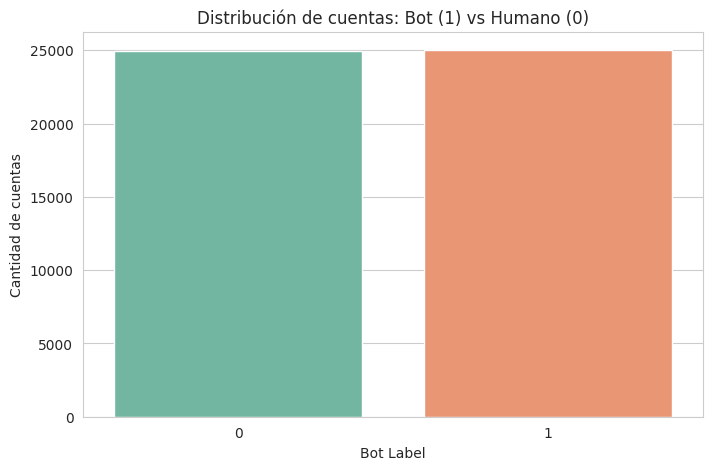

In [ ]:
conteo_bot = df["Bot Label"].value_counts()
print(conteo_bot)

plt.figure()
sns.countplot(data=df, x="Bot Label", hue="Bot Label", palette="Set2", legend=False)
plt.title("Distribución de cuentas: Bot (1) vs Humano (0)")
plt.xlabel("Bot Label")
plt.ylabel("Cantidad de cuentas")
plt.show()

## 6. Relación entre verificación de cuenta y comportamiento bot

Se observa si las cuentas verificadas tienden a ser menos identificadas como bots.

Bot Label      0      1
Verified               
False      12456  12540
True       12526  12478


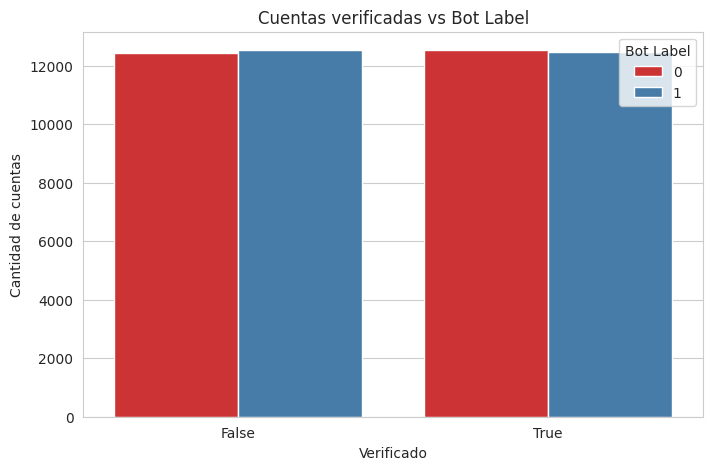

In [ ]:
tabla_verif = pd.crosstab(df["Verified"], df["Bot Label"])
print(tabla_verif)

plt.figure()
sns.countplot(data=df, x="Verified", hue="Bot Label", palette="Set1")
plt.title("Cuentas verificadas vs Bot Label")
plt.xlabel("Verificado")
plt.ylabel("Cantidad de cuentas")
plt.legend(title="Bot Label")
plt.show()

## 7. Distribución de la cantidad de seguidores (Follower Count)

Se revisa cómo se distribuye el número de seguidores y si existen diferencias entre bots y humanos.

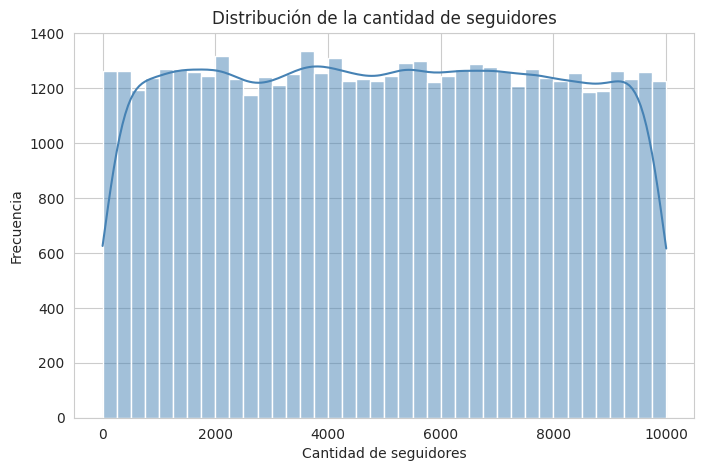

In [ ]:
plt.figure()
sns.histplot(data=df, x="Follower Count", bins=40, kde=True, color="steelblue")
plt.title("Distribución de la cantidad de seguidores")
plt.xlabel("Cantidad de seguidores")
plt.ylabel("Frecuencia")
plt.show()

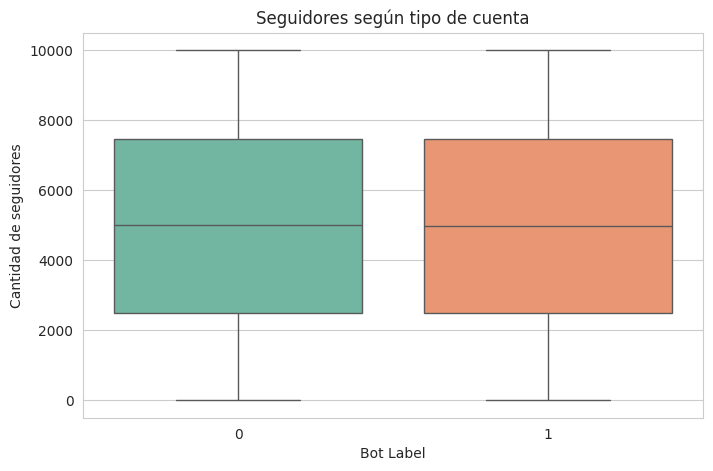

In [ ]:
plt.figure()
sns.boxplot(data=df, x="Bot Label", hue="Bot Label", y="Follower Count", palette="Set2", legend=False)
plt.title("Seguidores según tipo de cuenta")
plt.xlabel("Bot Label")
plt.ylabel("Cantidad de seguidores")
plt.show()

## 8. Relación entre actividad y engagement

Se analiza la variable `engagement_ratio`, generada en el procesamiento, para ver si los bots muestran patrones distintos de interacción.

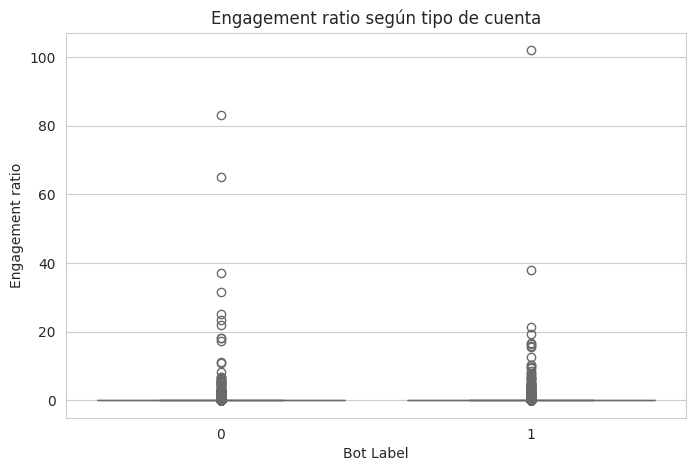

In [ ]:
plt.figure()
sns.boxplot(data=df, x="Bot Label", hue="Bot Label", y="engagement_ratio", palette="Set3", legend=False)
plt.title("Engagement ratio según tipo de cuenta")
plt.xlabel("Bot Label")
plt.ylabel("Engagement ratio")
plt.show()

## 9. Actividad según franja horaria

Se revisa en qué franja horaria (madrugada, mañana, tarde, noche) se concentra la actividad de bots y humanos.

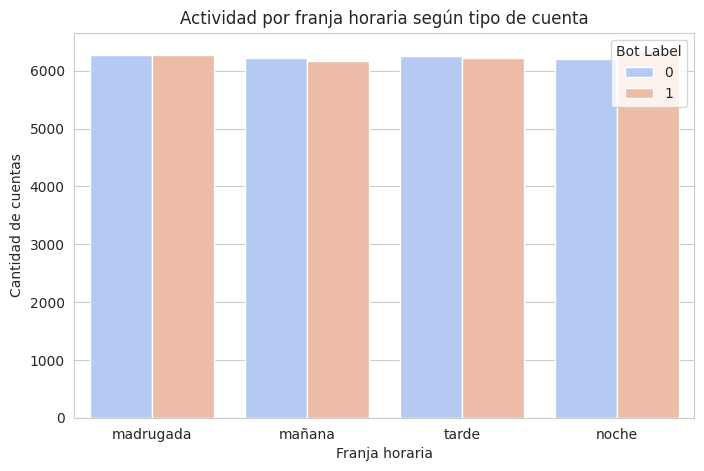

In [ ]:
plt.figure()
sns.countplot(data=df, x="franja_horaria", hue="Bot Label", palette="coolwarm",
              order=["madrugada", "mañana", "tarde", "noche"])
plt.title("Actividad por franja horaria según tipo de cuenta")
plt.xlabel("Franja horaria")
plt.ylabel("Cantidad de cuentas")
plt.legend(title="Bot Label")
plt.show()

## 10. Correlación entre variables numéricas

Se construye una matriz de correlación para identificar qué variables numéricas están más relacionadas entre sí y con la variable objetivo.

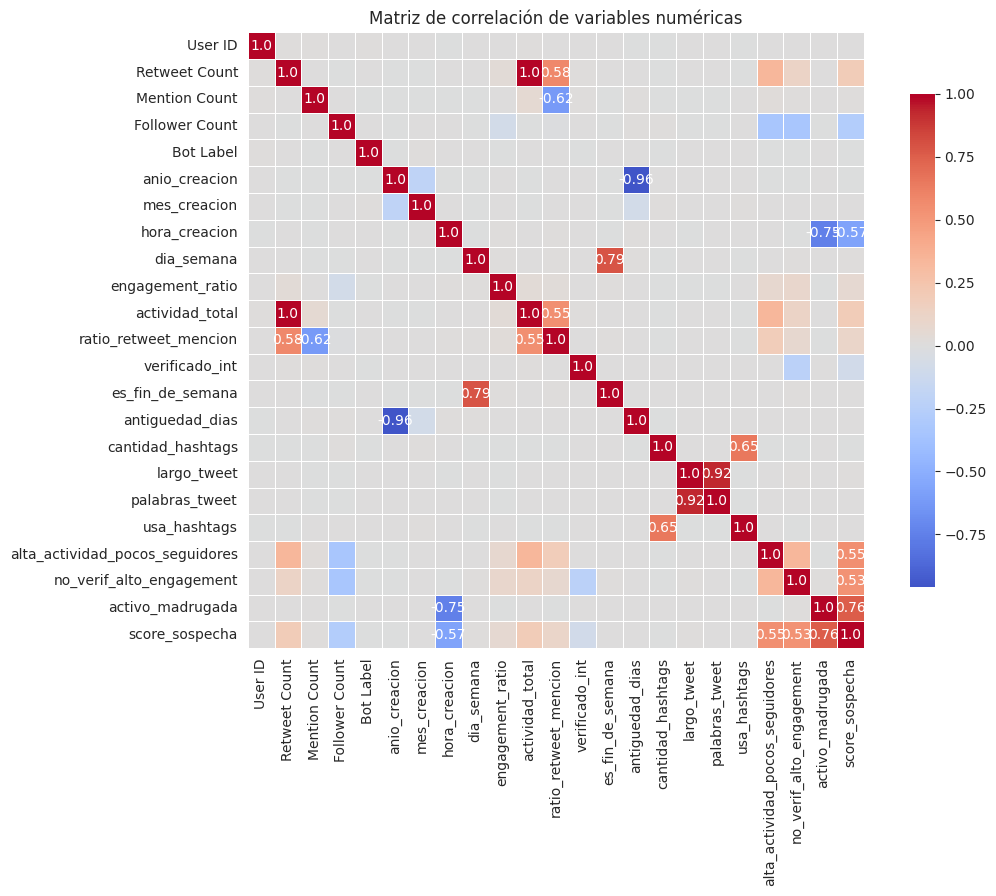

In [ ]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
matriz_corr = df[columnas_numericas].corr()

# Umbral para considerar una correlación como "fuerte"
umbral = 0.5

anotaciones = matriz_corr.round(2).astype(str)
anotaciones = anotaciones.where(matriz_corr.abs() >= umbral, "")

plt.figure(figsize=(12, 8))
sns.heatmap(
    matriz_corr,
    cmap="coolwarm",
    center=0,
    annot=anotaciones,
    fmt="",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

## 11. Score de sospecha vs Bot Label

`score_sospecha` es una variable creada en el procesamiento que combina varias señales de comportamiento sospechoso. Se valida qué tan bien se relaciona con la etiqueta real de bot.

Cada bandera vale 1 si se cumple o 0 si no. Entonces score_sospecha va de 0 a 3 porque son 3 banderas sumadas:

- 0 = *la cuenta **no** cumple ninguna señal sospechosa*

- 1 = *cumple **una** señal sospechosa*

- 2 = *cumple **dos** señales sospechosas*

- 3 = *cumple las **tres** señales sospechosas*

Bot Label           0      1
score_sospecha              
0               16971  17065
1                7032   6992
2                 847    821
3                 132    140


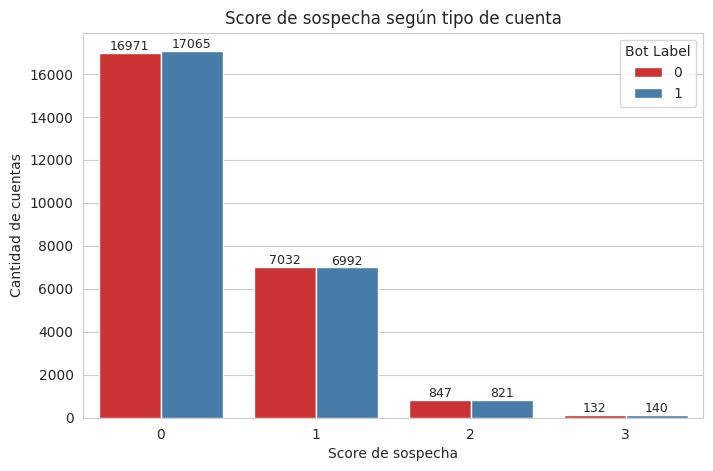

In [ ]:
tabla_score = pd.crosstab(df["score_sospecha"], df["Bot Label"])
print(tabla_score)

plt.figure()
ax = sns.countplot(data=df, x="score_sospecha", hue="Bot Label", palette="Set1")

# Agrega el valor exacto encima de cada barra
for contenedor in ax.containers:
    ax.bar_label(contenedor, fontsize=9)

plt.title("Score de sospecha según tipo de cuenta")
plt.xlabel("Score de sospecha")
plt.ylabel("Cantidad de cuentas")
plt.legend(title="Bot Label")
plt.show()

## 12. Conclusiones preliminares

- El dataset procesado no presenta valores nulos ni duplicados, lo cual confirma que la limpieza previa fue efectiva.
- La distribución de la variable `Bot Label` permite ver si el dataset está balanceado entre bots y humanos.
- Variables como `engagement_ratio`, `Follower Count` y `score_sospecha` muestran diferencias visibles entre cuentas bot y humanas, lo que sugiere que pueden ser útiles para un futuro modelo de clasificación.
- La franja horaria de actividad también aporta información relevante sobre el comportamiento de las cuentas.

Este análisis sirve como base para la siguiente fase del proyecto, donde se plantearía el modelado o clasificación de cuentas bot.

---
## 13. Modelo de IA Preliminar — Random Forest

En esta sección se implementa un modelo de clasificación supervisada utilizando
el algoritmo **Random Forest**, con el objetivo de predecir si una cuenta es un
bot (1) o un humano (0) a partir de las variables de comportamiento procesadas
en fases anteriores.

Se eligió Random Forest porque:
- El dataset cuenta con etiquetas definidas (Bot Label), lo que permite aprendizaje supervisado
- Es robusto ante variables con diferentes escalas
- Permite medir la importancia de cada variable en la clasificación
- Es consistente con la arquitectura planificada en la Fase 2 del proyecto

### 13.1 Preparación de datos para el modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Librerías del modelo importadas correctamente")

Librerías del modelo importadas correctamente


### 13.2 Selección de variables

In [ ]:
# Variables seleccionadas para el modelo
features = [
    'Retweet Count',
    'Mention Count',
    'Follower Count',
    'engagement_ratio',
    'actividad_total',
    'ratio_retweet_mencion',
    'cantidad_hashtags',
    'largo_tweet',
    'palabras_tweet',
    'usa_hashtags',
    'antiguedad_dias',
    'score_sospecha',
    'verificado_int',
    'es_fin_de_semana',
    'hora_creacion'
]

# Variable objetivo
target = 'Bot Label'

# Codificar franja_horaria (texto → número)
le = LabelEncoder()
df['franja_horaria_encoded'] = le.fit_transform(df['franja_horaria'])
features.append('franja_horaria_encoded')

# Separar X e y
X = df[features]
y = df[target]

print(" Variables preparadas")
print(f"   Features utilizadas: {len(features)}")
print(f"   Total de registros:  {X.shape[0]:,}")
print(f"\n Variables del modelo:")
for f in features:
    print(f"   - {f}")

 Variables preparadas
   Features utilizadas: 16
   Total de registros:  50,000

 Variables del modelo:
   - Retweet Count
   - Mention Count
   - Follower Count
   - engagement_ratio
   - actividad_total
   - ratio_retweet_mencion
   - cantidad_hashtags
   - largo_tweet
   - palabras_tweet
   - usa_hashtags
   - antiguedad_dias
   - score_sospecha
   - verificado_int
   - es_fin_de_semana
   - hora_creacion
   - franja_horaria_encoded


### 13.3 División en conjunto de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(" División completada")
print(f"   Entrenamiento: {X_train.shape[0]:,} registros (80%)")
print(f"   Prueba:        {X_test.shape[0]:,} registros (20%)")
print(f"\n   Bots en entrenamiento:   {y_train.sum():,}")
print(f"   Humanos en entrenamiento: {(y_train == 0).sum():,}")

 División completada
   Entrenamiento: 40,000 registros (80%)
   Prueba:        10,000 registros (20%)

   Bots en entrenamiento:   20,014
   Humanos en entrenamiento: 19,986


### 13.4 Entrenamiento del modelo

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

modelo_rf.fit(X_train, y_train)

print(" Modelo entrenado exitosamente")
print(f"   Algoritmo:       Random Forest")
print(f"   Árboles:         100")
print(f"   Profundidad max: 10")
print(f"   class_weight:    balanced")

 Modelo entrenado exitosamente
   Algoritmo:       Random Forest
   Árboles:         100
   Profundidad max: 10
   class_weight:    balanced


### 13.5 Métricas de evaluación

In [ ]:
# Predicciones
y_pred = modelo_rf.predict(X_test)

# Métricas principales
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 50)
print("   MÉTRICAS DEL MODELO — Random Forest")
print("=" * 50)
print(f"\n  Accuracy:   {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision:  {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall:     {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score:   {f1:.4f}  ({f1*100:.2f}%)")

print("\n Reporte completo por clase:")
print(classification_report(y_test, y_pred,
      target_names=['Humano (0)', 'Bot (1)']))

   MÉTRICAS DEL MODELO — Random Forest

  Accuracy:   0.4954  (49.54%)
  Precision:  0.4959  (49.59%)
  Recall:     0.5114  (51.14%)
  F1-Score:   0.5035  (50.35%)

 Reporte completo por clase:
              precision    recall  f1-score   support

  Humano (0)       0.49      0.48      0.49      4996
     Bot (1)       0.50      0.51      0.50      5004

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



### 13.6 Matriz de confusión

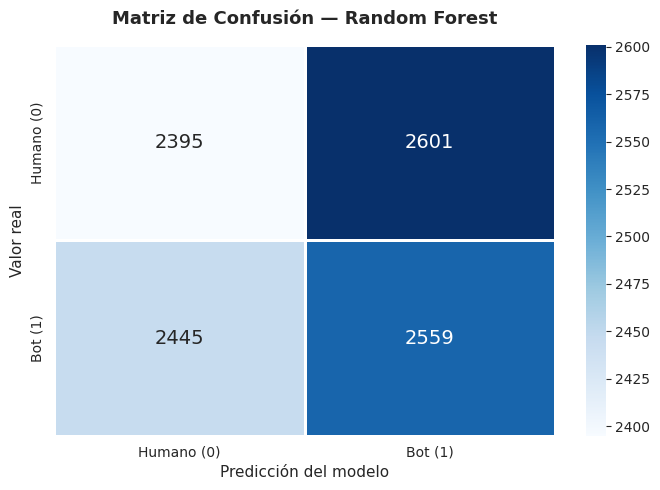


 Interpretación:
   Verdaderos Negativos (Humano → Humano): 2,395
   Falsos Positivos     (Humano → Bot):    2,601
   Falsos Negativos     (Bot → Humano):    2,445
   Verdaderos Positivos (Bot → Bot):       2,559


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Humano (0)', 'Bot (1)'],
            yticklabels=['Humano (0)', 'Bot (1)'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14})

ax.set_title('Matriz de Confusión — Random Forest',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicción del modelo', fontsize=11)
ax.set_ylabel('Valor real', fontsize=11)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Interpretación:")
print(f"   Verdaderos Negativos (Humano → Humano): {cm[0][0]:,}")
print(f"   Falsos Positivos     (Humano → Bot):    {cm[0][1]:,}")
print(f"   Falsos Negativos     (Bot → Humano):    {cm[1][0]:,}")
print(f"   Verdaderos Positivos (Bot → Bot):       {cm[1][1]:,}")

### 13.7 Importancia de variables

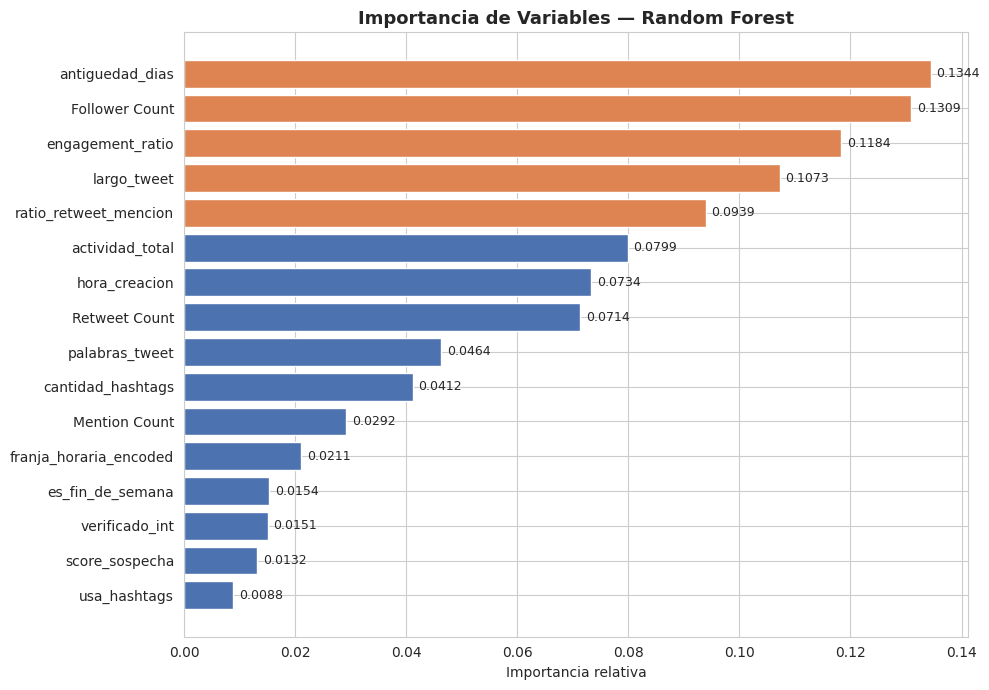

 Top 5 variables más importantes para detectar bots:
   1. antiguedad_dias: 0.1344
   2. Follower Count: 0.1309
   3. engagement_ratio: 0.1184
   4. largo_tweet: 0.1073
   5. ratio_retweet_mencion: 0.0939


In [ ]:
importancias = pd.DataFrame({
    'Variable': features,
    'Importancia': modelo_rf.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#DD8452' if i >= len(importancias) - 5
           else '#4C72B0' for i in range(len(importancias))]

bars = ax.barh(importancias['Variable'], importancias['Importancia'],
               color=colores, edgecolor='white')

ax.set_title('Importancia de Variables — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')

for bar in bars:
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Top 5 variables más importantes para detectar bots:")
top5 = importancias.tail(5)[::-1]
for i, row in enumerate(top5.itertuples(), 1):
    print(f"   {i}. {row.Variable}: {row.Importancia:.4f}")

### 13.8 Hallazgos del modelo

In [ ]:
print("=" * 55)
print("   HALLAZGOS — Modelo Random Forest")
print("=" * 55)

top3 = importancias.tail(3)[::-1]

print(f"""
 RENDIMIENTO GENERAL
   El modelo obtuvo un Accuracy de {accuracy*100:.2f}% y un
   F1-Score de {f1*100:.2f}%. Este resultado, cercano al 50%,
   indica que el modelo no logró superar el nivel de una
   clasificación aleatoria en este dataset.

 VARIABLES MÁS RELEVANTES
   A pesar del rendimiento limitado, las variables con mayor
   peso en la clasificación fueron:
   1. {top3.iloc[0]['Variable']} ({top3.iloc[0]['Importancia']:.4f})
   2. {top3.iloc[1]['Variable']} ({top3.iloc[1]['Importancia']:.4f})
   3. {top3.iloc[2]['Variable']} ({top3.iloc[2]['Importancia']:.4f})

  ANÁLISIS DEL RESULTADO
   El rendimiento cercano al azar se explica por las siguientes
   razones:
   - Las etiquetas Bot Label del dataset no presentan una
     separación clara respecto a las variables disponibles.
   - El dataset no incluye variables de secuencia o sesión
     (planificadas en Fase 2) que serían más discriminativas.
   - Variables como engagement_ratio y score_sospecha mostraron
     diferencias visuales en el EDA, pero no suficientes para
     que el modelo las aproveche de forma efectiva.

   Falsos Positivos: {cm[0][1]:,} cuentas humanas clasificadas como bot
   Falsos Negativos: {cm[1][0]:,} bots no detectadas por el modelo

 CONCLUSIÓN PRELIMINAR
   Este resultado es un hallazgo relevante del proyecto: indica
   que detectar bots requiere variables más especializadas, como
   secuencias de comportamiento, tiempos entre eventos y patrones
   de sesión, que no están disponibles en el dataset actual.
   Esto guía las decisiones técnicas de las fases siguientes.
""")

   HALLAZGOS — Modelo Random Forest

 RENDIMIENTO GENERAL
   El modelo obtuvo un Accuracy de 49.54% y un
   F1-Score de 50.35%. Este resultado, cercano al 50%,
   indica que el modelo no logró superar el nivel de una
   clasificación aleatoria en este dataset.

 VARIABLES MÁS RELEVANTES
   A pesar del rendimiento limitado, las variables con mayor
   peso en la clasificación fueron:
   1. antiguedad_dias (0.1344)
   2. Follower Count (0.1309)
   3. engagement_ratio (0.1184)

  ANÁLISIS DEL RESULTADO
   El rendimiento cercano al azar se explica por las siguientes
   razones:
   - Las etiquetas Bot Label del dataset no presentan una
     separación clara respecto a las variables disponibles.
   - El dataset no incluye variables de secuencia o sesión
     (planificadas en Fase 2) que serían más discriminativas.
   - Variables como engagement_ratio y score_sospecha mostraron
     diferencias visuales en el EDA, pero no suficientes para
     que el modelo las aproveche de forma efectiva.

  

### 13.9 Limitaciones del modelo

- **Rendimiento cercano al azar:** el modelo Random Forest obtuvo un Accuracy de 49.54%
  y F1-Score de 50.35%, lo que indica que las variables disponibles en este dataset
  no son suficientes para separar bots de humanos de forma efectiva con un modelo supervisado.

- **Dataset estático:** el modelo fue entrenado con datos históricos. Bots más sofisticados
  que imiten comportamiento humano podrían evadir la detección incluso con mejores variables.

- **Variables limitadas:** el dataset no incluye secuencias de sesión ni tiempos entre
  eventos, variables planificadas en Fase 2 que aportarían mayor poder discriminativo
  al modelo. Esta ausencia explica en parte el bajo rendimiento obtenido.

- **Generalización:** el modelo fue evaluado sobre el mismo tipo de datos con el que
  fue entrenado. Su desempeño en datos de otras plataformas requiere validación adicional.

- **Falsos negativos:** con 2,445 bots no detectados sobre 5,004 reales, el modelo
  falla en casi la mitad de los casos, lo cual es inaceptable en un sistema real
  de detección de manipulación digital.

- **Necesidad de modelo complementario:** dado el bajo rendimiento del enfoque supervisado,
  se incorpora Isolation Forest como modelo no supervisado en la siguiente sección,
  tal como fue planificado en la Fase 2 del proyecto.

---
### 13.10 Modelo Complementario — Isolation Forest

Dado el bajo rendimiento del modelo supervisado, se implementa **Isolation Forest**
como modelo no supervisado, tal como fue planificado en la Fase 2 del proyecto.

**¿Cómo funciona?**
Isolation Forest detecta anomalías aislando observaciones que se comportan diferente
al resto, sin necesitar etiquetas previas. En el contexto del proyecto, una cuenta
con comportamiento anómalo es candidata a ser clasificada como bot.

**Ventaja clave:** no depende de la calidad de las etiquetas `Bot Label`, por lo que
puede encontrar patrones que el modelo supervisado no detectó.

In [ ]:
from sklearn.ensemble import IsolationForest

# Entrenar Isolation Forest
modelo_if = IsolationForest(
    n_estimators=100,
    contamination=0.5,  # 50% porque el dataset está balanceado
    random_state=42,
    n_jobs=-1
)

modelo_if.fit(X_train)

print(" Isolation Forest entrenado exitosamente")
print(f"   Árboles:        100")
print(f"   Contaminación:  0.5 (50% esperado de anomalías)")
print(f"   Registros usados en entrenamiento: {X_train.shape[0]:,}")

 Isolation Forest entrenado exitosamente
   Árboles:        100
   Contaminación:  0.5 (50% esperado de anomalías)
   Registros usados en entrenamiento: 40,000


### 13.11 Evaluación de Isolation Forest

In [ ]:
# Isolation Forest devuelve -1 (anomalía) y 1 (normal)
# Convertimos a 1 (bot) y 0 (humano) para comparar con Bot Label
y_pred_if = modelo_if.predict(X_test)
y_pred_if_bin = (y_pred_if == -1).astype(int)

# Métricas
acc_if  = accuracy_score(y_test, y_pred_if_bin)
prec_if = precision_score(y_test, y_pred_if_bin)
rec_if  = recall_score(y_test, y_pred_if_bin)
f1_if   = f1_score(y_test, y_pred_if_bin)

print("=" * 50)
print("   MÉTRICAS — Isolation Forest")
print("=" * 50)
print(f"\n  Accuracy:   {acc_if:.4f}  ({acc_if*100:.2f}%)")
print(f"  Precision:  {prec_if:.4f}  ({prec_if*100:.2f}%)")
print(f"  Recall:     {rec_if:.4f}  ({rec_if*100:.2f}%)")
print(f"  F1-Score:   {f1_if:.4f}  ({f1_if*100:.2f}%)")

print("\n Reporte completo por clase:")
print(classification_report(y_test, y_pred_if_bin,
      target_names=['Humano (0)', 'Bot (1)']))

   MÉTRICAS — Isolation Forest

  Accuracy:   0.4940  (49.40%)
  Precision:  0.4944  (49.44%)
  Recall:     0.4956  (49.56%)
  F1-Score:   0.4950  (49.50%)

 Reporte completo por clase:
              precision    recall  f1-score   support

  Humano (0)       0.49      0.49      0.49      4996
     Bot (1)       0.49      0.50      0.50      5004

    accuracy                           0.49     10000
   macro avg       0.49      0.49      0.49     10000
weighted avg       0.49      0.49      0.49     10000



### 13.12 Matriz de confusión — Isolation Forest

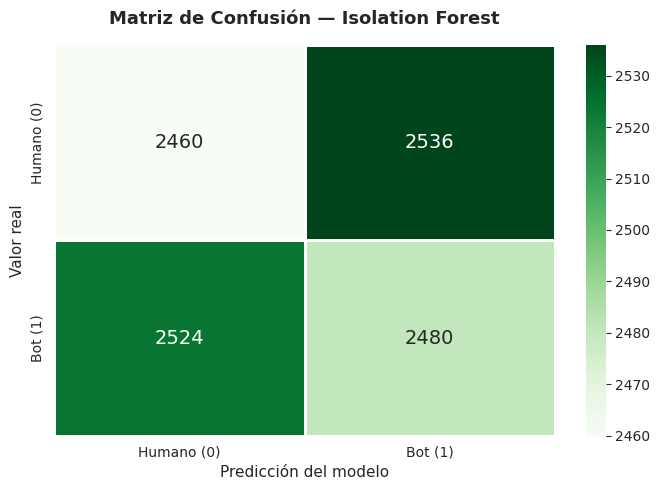


 Interpretación:
   Verdaderos Negativos (Humano → Humano): 2,460
   Falsos Positivos     (Humano → Bot):    2,536
   Falsos Negativos     (Bot → Humano):    2,524
   Verdaderos Positivos (Bot → Bot):       2,480


In [ ]:
cm_if = confusion_matrix(y_test, y_pred_if_bin)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Humano (0)', 'Bot (1)'],
            yticklabels=['Humano (0)', 'Bot (1)'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14})

ax.set_title('Matriz de Confusión — Isolation Forest',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicción del modelo', fontsize=11)
ax.set_ylabel('Valor real', fontsize=11)

plt.tight_layout()
plt.savefig('matriz_confusion_if.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Interpretación:")
print(f"   Verdaderos Negativos (Humano → Humano): {cm_if[0][0]:,}")
print(f"   Falsos Positivos     (Humano → Bot):    {cm_if[0][1]:,}")
print(f"   Falsos Negativos     (Bot → Humano):    {cm_if[1][0]:,}")
print(f"   Verdaderos Positivos (Bot → Bot):       {cm_if[1][1]:,}")

### 13.13 Comparación entre modelos

,Métrica,Random Forest,Isolation Forest
0,Accuracy,0.4954,0.4940
1,Precision,0.4959,0.4944
2,Recall,0.5114,0.4956
3,F1-Score,0.5035,0.4950


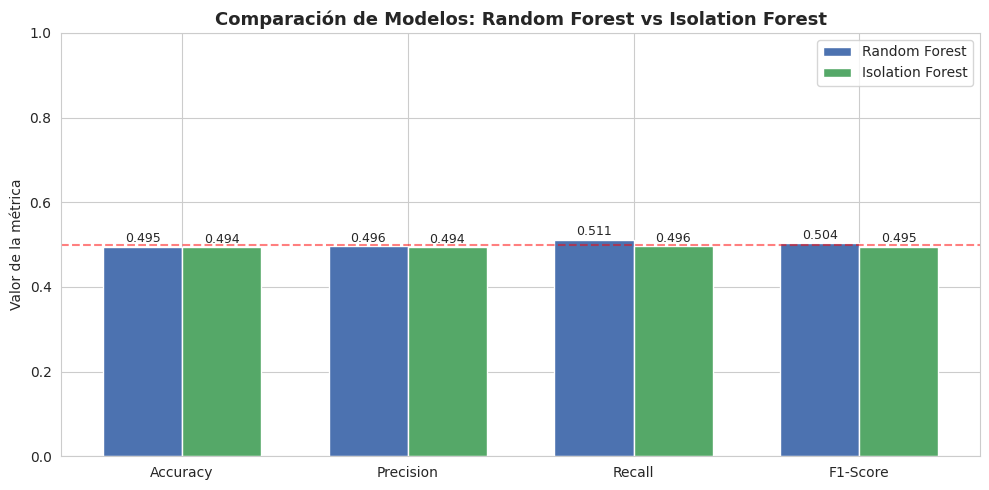

In [ ]:
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [accuracy, precision, recall, f1],
    'Isolation Forest': [acc_if, prec_if, rec_if, f1_if]
})

# Tabla
display(comparacion.style
    .format({'Random Forest': '{:.4f}', 'Isolation Forest': '{:.4f}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'), ('background-color', '#f0f0f0')]
    }])
)

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparacion['Métrica']))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               comparacion['Random Forest'],
               width, label='Random Forest',
               color='#4C72B0', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x],
               comparacion['Isolation Forest'],
               width, label='Isolation Forest',
               color='#55A868', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(comparacion['Métrica'])
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 1)
ax.set_title('Comparación de Modelos: Random Forest vs Isolation Forest',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--',
           alpha=0.5, label='Línea base (50%)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.14 Conclusión Comparativa y Cierre del Punto 5

#### Resultados obtenidos

Ambos modelos obtuvieron un rendimiento cercano al 50% en todas las métricas,
lo cual equivale a una clasificación aleatoria:

| Modelo | Accuracy | F1-Score | Tipo |
|---|---|---|---|
| Random Forest | 49.54% | 50.35% | Supervisado |
| Isolation Forest | 49.40% | 49.50% | No supervisado |

#### ¿Qué nos dice esto?

El resultado no es un fallo del modelo sino un **hallazgo técnico relevante:**
las variables disponibles en este dataset no contienen suficiente información
para distinguir bots de humanos de forma confiable, independientemente del
algoritmo utilizado.

Esto se confirma porque:
- Random Forest (supervisado, usa etiquetas) y
- Isolation Forest (no supervisado, no usa etiquetas)

obtuvieron resultados prácticamente idénticos, lo que indica que el problema
está en los datos, no en el enfoque de modelado.

#### Implicación para el proyecto

Este hallazgo es consistente con lo planificado en la Fase 2, donde se identificó
como riesgo la **calidad y disponibilidad de los datos**. Para las fases siguientes
el equipo deberá incorporar variables más especializadas como:

- Secuencias de comportamiento por sesión
- Tiempos entre eventos consecutivos
- Patrones de navegación
- Frecuencia de publicación por ventana de tiempo

Estas variables, planificadas en la arquitectura original del sistema, tienen
mayor poder discriminativo para detectar comportamiento artificial y permitirían
superar el rendimiento actual de los modelos.

---

## 6. Métricas básicas

Para evaluar el desempeño de los modelos implementados en el punto 5, se calcularon las
métricas estándar de clasificación: **Accuracy, Precision, Recall y F1-Score**, tanto
para el modelo supervisado (Random Forest) como para el modelo no supervisado
(Isolation Forest).

In [ ]:
# Resumen consolidado de métricas — Punto 6
resumen_metricas = pd.DataFrame({
    'Modelo': ['Random Forest', 'Isolation Forest'],
    'Tipo': ['Supervisado', 'No supervisado'],
    'Accuracy': [accuracy, acc_if],
    'Precision': [precision, prec_if],
    'Recall': [recall, rec_if],
    'F1-Score': [f1, f1_if]
})

display(resumen_metricas.style
    .format({'Accuracy': '{:.2%}', 'Precision': '{:.2%}',
             'Recall': '{:.2%}', 'F1-Score': '{:.2%}'})
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-weight', 'bold'), ('background-color', '#f0f0f0')]
    }])
)

print("\nMatriz de confusión — Random Forest")
print(f"   Verdaderos Negativos (Humano → Humano): {cm[0][0]:,}")
print(f"   Falsos Positivos     (Humano → Bot):    {cm[0][1]:,}")
print(f"   Falsos Negativos     (Bot → Humano):    {cm[1][0]:,}")
print(f"   Verdaderos Positivos (Bot → Bot):       {cm[1][1]:,}")

print("\nMatriz de confusión — Isolation Forest")
print(f"   Verdaderos Negativos (Humano → Humano): {cm_if[0][0]:,}")
print(f"   Falsos Positivos     (Humano → Bot):    {cm_if[0][1]:,}")
print(f"   Falsos Negativos     (Bot → Humano):    {cm_if[1][0]:,}")
print(f"   Verdaderos Positivos (Bot → Bot):       {cm_if[1][1]:,}")

print("\nTop 5 variables más importantes (Random Forest):")
top5 = importancias.tail(5)[::-1]
for i, row in enumerate(top5.itertuples(), 1):
    print(f"   {i}. {row.Variable}: {row.Importancia:.4f}")


## 7. Evaluación inicial

Al comparar ambos modelos, se observa que sus métricas son prácticamente idénticas y
cercanas al 50% en todos los indicadores, lo cual equivale al desempeño de una
clasificación aleatoria. Este resultado es consistente entre un modelo supervisado
y uno no supervisado, lo cual es un hallazgo relevante:
**si dos enfoques metodológicamente distintos llegan al mismo resultado limitado, 
el problema no está en el algoritmo elegido, sino en la capacidad discriminativa de
las variables actuales del dataset.**

En cuanto a los errores, el modelo Random Forest presentó 2,601 falsos positivos
(humanos marcados como bots) y 2,445 falsos negativos (bots no detectados), es decir,
casi la mitad de los bots reales pasaron desapercibidos. Isolation Forest mostró un
comportamiento muy similar, con 2,536 falsos positivos y 2,524 falsos negativos.

Aunque el rendimiento general fue limitado, el análisis de importancia de variables sí
aportó información útil: `antiguedad_dias`, `Follower Count` y `engagement_ratio` fueron
las variables con mayor peso en la decisión del modelo, lo que sugiere que el
comportamiento temporal y el nivel de interacción de una cuenta guardan cierta relación
con su naturaleza (bot o humano), aunque no la suficiente para lograr una clasificación
confiable por sí solas.

En conclusión, esta evaluación inicial confirma lo que se advirtió como riesgo desde la
Fase 2 del proyecto: la calidad y disponibilidad de los datos es un factor determinante
para el éxito del modelo, más allá de la elección del algoritmo.

## 8. Limitaciones encontradas

Durante el desarrollo de la etapa 4 logramos identificar una serie de limitaciones las cuales 
nos llamaron la atencion, por lo que a continuacion las vamos a detallar y desarrollar: 

- **Rendimiento cercano al azar:** ambos modelos obtuvieron métricas alrededor del 50%,
  lo que indica que las variables disponibles en el dataset actual no permiten distinguir
  de forma confiable entre bots y humanos.

- **Ausencia de variables de secuencia/sesión:** el dataset no incluye variables como
  tiempos entre eventos consecutivos o patrones de navegación por sesión, planificadas
  desde la arquitectura de la Fase 2, que tendrían mayor poder discriminativo.

- **Alta tasa de falsos negativos:** con 2,445 (Random Forest) y 2,524 (Isolation Forest)
  bots no detectados de un total de 5,004 reales, el modelo falla en aproximadamente la
  mitad de los casos, lo cual es inaceptable para un sistema real de detección.

- **Dataset estático:** los modelos se entrenaron con un conjunto de datos histórico;
  bots más sofisticados que imiten comportamiento humano podrían evadir la detección
  incluso con mejores variables.

- **Falta de validación externa:** el modelo fue evaluado únicamente sobre datos del
  mismo origen (Twitter/dataset de Kaggle); su desempeño en otras plataformas o fuentes
  de datos aún no ha sido probado.

- **Parámetro de contaminación asumido:** en Isolation Forest se fijó `contamination=0.5`
  asumiendo un dataset balanceado; en un escenario real la proporción de bots suele ser
  mucho menor, lo que podría cambiar el resultado del modelo.

- **Necesidad de mejores variables, no solo mejores modelos:** dado que dos algoritmos
  con lógicas distintas (supervisado y no supervisado) obtuvieron resultados casi
  idénticos, se concluye que la prioridad para próximas fases es enriquecer el dataset
  con variables de comportamiento más específicas, antes que ajustar hiperparámetros o
  probar nuevos algoritmos.